# 结果展示与报告图表：IC 时间分析与 Top 组合分析

**Day 8 / Day 6+9（成员 B）**：对固定验证预测 `E001_baseline_repeat`（V1 40 特征 / LightGBM 200 轮基线，8 项指标与 `E000_baseline_retry1` 逐位一致）做两组诊断：

1. **IC 时间分析**（第 1–5 节）：逐日 / 月度 / 季度 IC，回答"模型是稳定赚钱，还是只靠少数月份"；
2. **Top 组合分析**（第 6 节，复用 `src/evaluation/backtest.py`）：官方口径 Top 10% 组合的逐日收益、市场基准、超额与多空价差，扩展 Top 20% / Bottom 10% 诊断。

Top 组口径与 `official_eval.py` 完全一致（剔涨停 + 剔 y 缺失 → pred 降序 → 前 10% → 相对同口径全体的超额，年化 × 252），并在第 6 节入口做逐日 / 年化双重核对。数据来源：`outputs/predictions/E001_baseline_repeat/valid_2024.csv` 与 `outputs/metrics/E001_baseline_repeat/`（2024 验证期 242 个交易日）。

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXP = "E001_baseline_repeat"
MET_DIR = ROOT / "outputs" / "metrics" / EXP
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

daily = pd.read_csv(MET_DIR / "daily_metrics.csv", dtype={"trade_date": str})
metrics = json.load(open(MET_DIR / "metrics.json", encoding="utf-8"))

# 与 metrics.json 的汇总口径核对（同一数据、两条入口）
assert len(daily) == metrics["n_days_ic"] == 242
assert int(daily["turnover"].notna().sum()) == metrics["n_days_turnover"] == 241
assert abs(daily["ic"].mean() - metrics["ic_mean"]) < 1e-12
assert abs(daily["ic"].std(ddof=1) - metrics["ic_std"]) < 1e-12
assert abs((daily["ic"] > 0).mean() - metrics["ic_positive_ratio"]) < 1e-12

daily["date"] = pd.to_datetime(daily["trade_date"], format="%Y%m%d")
print("核对通过：daily_metrics 逐日值与 metrics.json 汇总口径一致")
print(f"IC_mean = {metrics['ic_mean']:.6f}   IC_std = {metrics['ic_std']:.6f}   "
      f"ICIR = {metrics['icir']:.4f}")
print(f"正 IC 天数比例 = {metrics['ic_positive_ratio']:.2%}   "
      f"交易日 = {len(daily)} 天（2024-01-02 ~ 2024-12-31，首日无换手）")

核对通过：daily_metrics 逐日值与 metrics.json 汇总口径一致
IC_mean = 0.090766   IC_std = 0.139836   ICIR = 0.6491
正 IC 天数比例 = 77.27%   交易日 = 242 天（2024-01-02 ~ 2024-12-31，首日无换手）


## 1. 逐日 IC

看三件事：波动幅度（IC_std）、20 日滚动均值是否长期为正、极端日出现在什么时点。

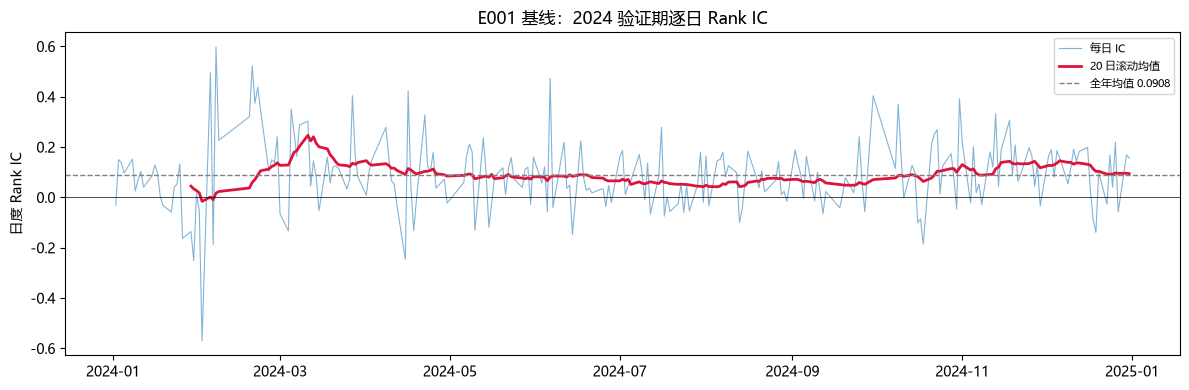

日度 IC 分位数：
0.050000   -0.117586
0.250000    0.011336
0.500000    0.081789
0.750000    0.164290
0.950000    0.346571

最差 5 天：
trade_date        ic
  20240202 -0.569814
  20240130 -0.250779
  20240415 -0.245783
  20240206 -0.186774
  20241018 -0.185747

最好 5 天：
trade_date       ic
  20240207 0.597550
  20240220 0.522654
  20240205 0.494914
  20240606 0.473494
  20240222 0.438343


In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["date"], daily["ic"], lw=0.8, alpha=0.55, label="每日 IC")
ax.plot(daily["date"], daily["ic"].rolling(20).mean(), lw=2, color="crimson",
        label="20 日滚动均值")
ax.axhline(metrics["ic_mean"], ls="--", lw=1, color="gray",
           label=f"全年均值 {metrics['ic_mean']:.4f}")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("日度 Rank IC")
ax.set_title("E001 基线：2024 验证期逐日 Rank IC")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "ic_daily_E001.png", dpi=150)
plt.show()

q = daily["ic"].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
print("日度 IC 分位数：")
print(q.to_string())
print("\n最差 5 天：")
print(daily.nsmallest(5, "ic")[["trade_date", "ic"]].to_string(index=False))
print("\n最好 5 天：")
print(daily.nlargest(5, "ic")[["trade_date", "ic"]].to_string(index=False))

## 2. 累计 IC

逐日 IC 累加。若曲线接近直线，说明收益均匀来自全年；若呈台阶状，则集中在少数时段。

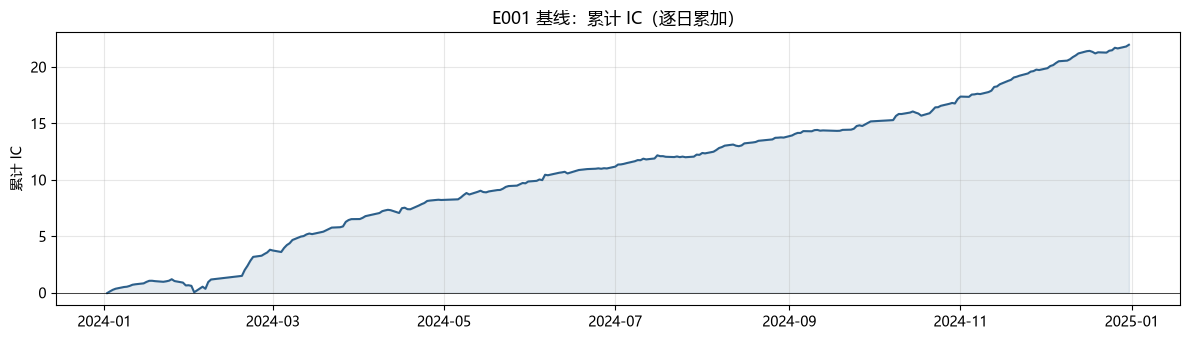

全年累计 IC = 21.97
累计 IC 为负的天数占比 = 0.41%


In [3]:
cum = daily["ic"].cumsum()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily["date"], cum, lw=1.5, color="#2c5f8a")
ax.fill_between(daily["date"], 0, cum, alpha=0.12, color="#2c5f8a")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("累计 IC")
ax.set_title("E001 基线：累计 IC（逐日累加）")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "ic_cumulative_E001.png", dpi=150)
plt.show()

print(f"全年累计 IC = {daily['ic'].sum():.2f}")
print(f"累计 IC 为负的天数占比 = {(cum < 0).mean():.2%}")

## 3. 月度 IC

月均 IC、月内日度 IC 波动、月度 ICIR、月内正 IC 天数比例。

In [4]:
daily["month"] = daily["date"].dt.strftime("%Y-%m")
g = daily.groupby("month")["ic"]
monthly = pd.DataFrame({
    "n_days": g.size(),
    "ic_mean": g.mean(),
    "ic_std": g.std(ddof=1),
    "icir": g.mean() / g.std(ddof=1),
    "pos_ratio": g.apply(lambda s: (s > 0).mean()),
})
print(monthly.to_string())
n_pos_month = (monthly["ic_mean"] > 0).sum()
print(f"\n12 个月中月均 IC 为正的月份：{n_pos_month} 个")

         n_days  ic_mean   ic_std     icir  pos_ratio
month                                                
2024-01      22 0.030086 0.107162 0.280754   0.727273
2024-02      15 0.209633 0.304219 0.689086   0.800000
2024-03      21 0.129136 0.136133 0.948605   0.857143
2024-04      20 0.084786 0.151362 0.560151   0.750000
2024-05      20 0.081921 0.100201 0.817571   0.800000
2024-06      19 0.060820 0.132449 0.459199   0.736842
2024-07      23 0.052412 0.096863 0.541096   0.652174
2024-08      22 0.069548 0.077862 0.893211   0.818182
2024-09      19 0.075340 0.115196 0.654018   0.736842
2024-10      18 0.110082 0.159005 0.692317   0.722222
2024-11      21 0.122428 0.104390 1.172790   0.857143
2024-12      22 0.101725 0.102597 0.991499   0.818182

12 个月中月均 IC 为正的月份：12 个


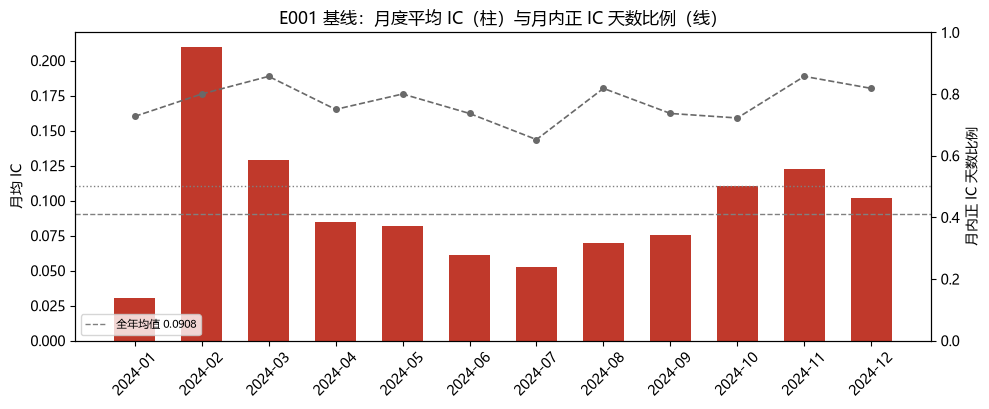

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.2))
colors = ["#c0392b" if v >= 0 else "#16a085" for v in monthly["ic_mean"]]
ax.bar(monthly.index, monthly["ic_mean"], color=colors, width=0.62)
ax.axhline(0, color="black", lw=0.6)
ax.axhline(metrics["ic_mean"], ls="--", lw=1, color="gray",
           label=f"全年均值 {metrics['ic_mean']:.4f}")
ax.set_ylabel("月均 IC")
ax.set_title("E001 基线：月度平均 IC（柱）与月内正 IC 天数比例（线）")
ax.tick_params(axis="x", rotation=45)
ax2 = ax.twinx()
ax2.plot(monthly.index, monthly["pos_ratio"], "o--", color="dimgray", lw=1.2, ms=4)
ax2.axhline(0.5, ls=":", color="gray", lw=1)
ax2.set_ylim(0, 1)
ax2.set_ylabel("月内正 IC 天数比例")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "ic_monthly_E001.png", dpi=150)
plt.show()

## 4. 季度 IC

In [6]:
daily["quarter"] = daily["date"].dt.year.astype(str) + "Q" + daily["date"].dt.quarter.astype(str)
gq = daily.groupby("quarter")["ic"]
quarterly = pd.DataFrame({
    "n_days": gq.size(),
    "ic_mean": gq.mean(),
    "icir": gq.mean() / gq.std(ddof=1),
    "pos_ratio": gq.apply(lambda s: (s > 0).mean()),
})
print(quarterly.to_string())

monthly.to_csv(MET_DIR / "ic_monthly.csv")
quarterly.to_csv(MET_DIR / "ic_quarterly.csv")
print("\n月度 / 季度汇总已保存至 outputs/metrics/E001_baseline_repeat/")

         n_days  ic_mean     icir  pos_ratio
quarter                                     
2024Q1       58 0.112384 0.571492   0.793103
2024Q2       59 0.076097 0.595077   0.762712
2024Q3       64 0.065109 0.679327   0.734375
2024Q4       61 0.111318 0.922623   0.803279

月度 / 季度汇总已保存至 outputs/metrics/E001_baseline_repeat/


## 5. 稳定性判定：集中还是均匀？

量化"只靠少数月份"的程度：剔除最好 / 最差若干个月后全年均值的变化、上下半年对比、月度 IC 的离散度。

In [7]:
w = daily.groupby("month")["ic"].agg(n_days="size", ic_sum="sum", ic_mean="mean")
total_sum = w["ic_sum"].sum()

best3 = w.nlargest(3, "ic_mean")
worst3 = w.nsmallest(3, "ic_mean")
drop_best3 = w.drop(best3.index)
drop_worst3 = w.drop(worst3.index)

def wmean(sub):
    return sub["ic_sum"].sum() / sub["n_days"].sum()

print("=== 集中度分解 ===")
print(f"全年日度 IC 均值:                {daily['ic'].mean():.6f}")
print(f"剔除最好 3 个月（{', '.join(best3.index)}）后:  {wmean(drop_best3):.6f}  "
      f"（保留 {wmean(drop_best3)/daily['ic'].mean():.1%}）")
print(f"剔除最差 3 个月（{', '.join(worst3.index)}）后:  {wmean(drop_worst3):.6f}  "
      f"（保留 {wmean(drop_worst3)/daily['ic'].mean():.1%}）")
print(f"最好 3 个月合计 IC 贡献占比:      {best3['ic_sum'].sum()/total_sum:.1%}")
print(f"最差 3 个月合计 IC 拖累占比:      {worst3['ic_sum'].sum()/total_sum:.1%}")

h1 = daily[daily["date"].dt.month <= 6]["ic"]
h2 = daily[daily["date"].dt.month >= 7]["ic"]
print("\n=== 上下半年对比 ===")
print(f"上半年: mean={h1.mean():.6f}  正比例={np.mean(h1 > 0):.2%}  ICIR={h1.mean()/h1.std(ddof=1):.4f}")
print(f"下半年: mean={h2.mean():.6f}  正比例={np.mean(h2 > 0):.2%}  ICIR={h2.mean()/h2.std(ddof=1):.4f}")

print("\n=== 月度离散度 ===")
cv = monthly["ic_mean"].std(ddof=1) / monthly["ic_mean"].mean()
print(f"月均 IC 的最小 / 最大:            {monthly['ic_mean'].min():.6f} / {monthly['ic_mean'].max():.6f}")
print(f"月均 IC 变异系数（std/mean）:     {cv:.4f}")

=== 集中度分解 ===
全年日度 IC 均值:                0.090766
剔除最好 3 个月（2024-02, 2024-03, 2024-11）后:  0.073178  （保留 80.6%）
剔除最差 3 个月（2024-01, 2024-07, 2024-06）后:  0.106418  （保留 117.2%）
最好 3 个月合计 IC 贡献占比:      38.4%
最差 3 个月合计 IC 拖累占比:      13.8%

=== 上下半年对比 ===
上半年: mean=0.094085  正比例=77.78%  ICIR=0.5672
下半年: mean=0.087659  正比例=76.80%  ICIR=0.7920

=== 月度离散度 ===
月均 IC 的最小 / 最大:            0.030086 / 0.209633
月均 IC 变异系数（std/mean）:     0.4951


## 结论

1. **判定：稳定赚钱型，不靠个别月份。** 12 个月月均 IC 全部为正（最小 2024-01 的 0.0301，最大 2024-02 的 0.2096）；正 IC 天数比例 77.27%；累计 IC 曲线除首日外全程为正、近似单调上升；四个季度 IC 均值落在 [0.065, 0.112] 的窄区间。
2. **集中度温和。** 最好的 3 个月（02/03/11，时间占比 25%）贡献全年累计 IC 的 38.4%；剔除后仍保留 80.6% 的日度 IC 均值。月均 IC 变异系数 0.495。
3. **脆弱点集中在 2024 年 1 月底–2 月初。** 全年 IC 最差 5 天中的 3 天（0130/0202/0206）与最好 5 天中的 3 天（0205/0207/0220）都出现在这约 4 周内，单日 IC 在 -0.57 到 +0.60 之间剧烈翻转；2 月 IC_std 0.304 为全年均值的 2.2 倍。该时段排序剧烈翻转与高换手直接相关，Day 10 换手分析需重点检查此段 turnover。
4. **下半年更稳。** H1 ICIR 0.567 / H2 0.792，IC 均值接近（0.094 / 0.088）。最弱月是 1 月（0.0301，全年唯一低于 0.05 的月份），2023/2025 是否同样存在“开年弱”模式，留给 Day 13 两折对照确认。
5. **对 Day 10–12 的含义：** IC 全年均匀为正意味着平滑降换手的代价大概率可控——过度平滑才会显著伤 IC。下一步（Day 9 Top 10% 分析）优先检查 1–2 月极端时段 Top 组的回撤与恢复。

## 6. Top 组合分析（Day 6 / 9）

官方 60% 的评分在 Top 组合与稳定性上。复用 `src/evaluation/backtest.py` 的逐日组合收益，先与官方口径双重核对，再看：累计净值、月度超额、多空价差、以及 Day 8 定位的 2024 年 1–2 月脆弱时段在组合层面的表现。

In [8]:
import sys
sys.path.insert(0, str(ROOT))
from src.evaluation.backtest import daily_portfolio_returns, load_scored, monthly_excess, summarize

scored = load_scored(ROOT / "outputs" / "predictions" / EXP / "valid_2024.csv",
                     MET_DIR / "validation_labels.csv")
bt_daily = daily_portfolio_returns(scored)
bt_summary = summarize(bt_daily)
bt_monthly = monthly_excess(bt_daily)

# 口径核对 1：逐日值与 official_eval 的 daily_metrics 完全一致
bt_daily["trade_date"] = bt_daily["trade_date"].astype(str)
_check = bt_daily.merge(daily, on="trade_date", how="inner", validate="one_to_one")
assert len(_check) == 242
assert (_check["top10_excess"] - _check["top_excess"]).abs().max() < 1e-15
# 口径核对 2：年化值与 metrics.json 完全一致
assert abs(bt_summary["top10_annual_ret"] - metrics["top1_annual_ret"]) < 1e-12
assert abs(bt_summary["annual_excess"] - metrics["annual_excess"]) < 1e-12
print("核对通过：Top 组合口径与 official_eval 逐日 / 年化均差 0")
print()
print(f"Top10 年化收益   {bt_summary['top10_annual_ret']:+.4f}    市场(同口径)年化 {bt_summary['market_annual_ret']:+.4f}")
print(f"年化超额         {bt_summary['annual_excess']:+.4f}    Top20 年化超额   {bt_summary['top20_annual_excess']:+.4f}")
print(f"Bottom10 年化    {bt_summary['bottom10_annual_ret']:+.4f}    多空年化价差     {bt_summary['top_bottom_annual_spread']:+.4f}")
print(f"日超额为正比例   {bt_summary['excess_positive_ratio']:.2%}")
print(f"Top10 绝对最大回撤 {bt_summary['top10_max_drawdown']:.2%}    相对市场最大回撤 {bt_summary['relative_max_drawdown']:.2%}")

核对通过：Top 组合口径与 official_eval 逐日 / 年化均差 0

Top10 年化收益   +0.3873    市场(同口径)年化 -0.0140
年化超额         +0.4013    Top20 年化超额   +0.3726
Bottom10 年化    -1.6819    多空年化价差     +2.0692
日超额为正比例   63.22%
Top10 绝对最大回撤 33.61%    相对市场最大回撤 8.95%


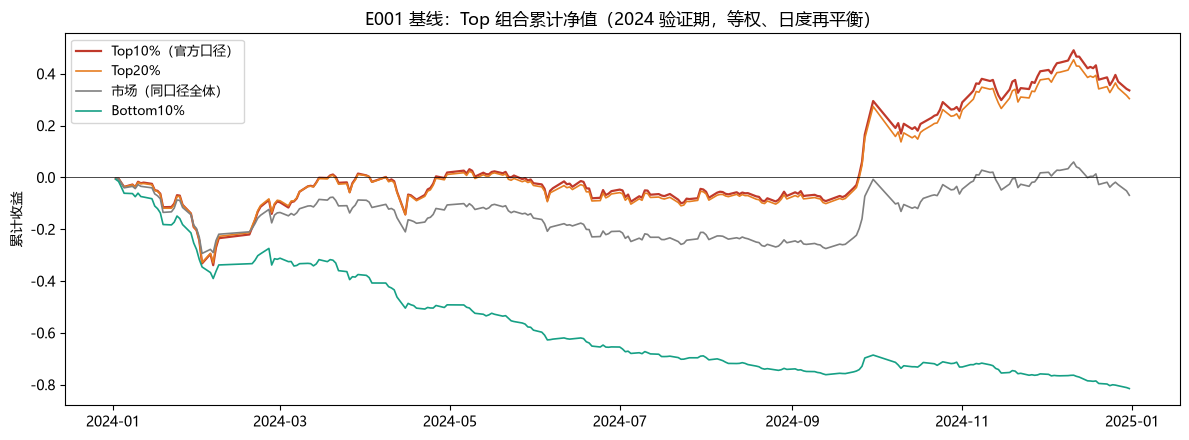

In [9]:
dates_bt = pd.to_datetime(bt_daily["trade_date"], format="%Y%m%d")
cum_top10 = (1 + bt_daily["top10_ret"]).cumprod()
cum_top20 = (1 + bt_daily["top20_ret"]).cumprod()
cum_mkt = (1 + bt_daily["market_ret"]).cumprod()
cum_bot = (1 + bt_daily["bottom10_ret"]).cumprod()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(dates_bt, cum_top10 - 1, lw=1.6, color="#c0392b", label="Top10%（官方口径）")
ax.plot(dates_bt, cum_top20 - 1, lw=1.2, color="#e67e22", label="Top20%")
ax.plot(dates_bt, cum_mkt - 1, lw=1.2, color="gray", label="市场（同口径全体）")
ax.plot(dates_bt, cum_bot - 1, lw=1.2, color="#16a085", label="Bottom10%")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("累计收益")
ax.set_title("E001 基线：Top 组合累计净值（2024 验证期，等权、日度再平衡）")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "top_cumulative_E001.png", dpi=150)
plt.show()

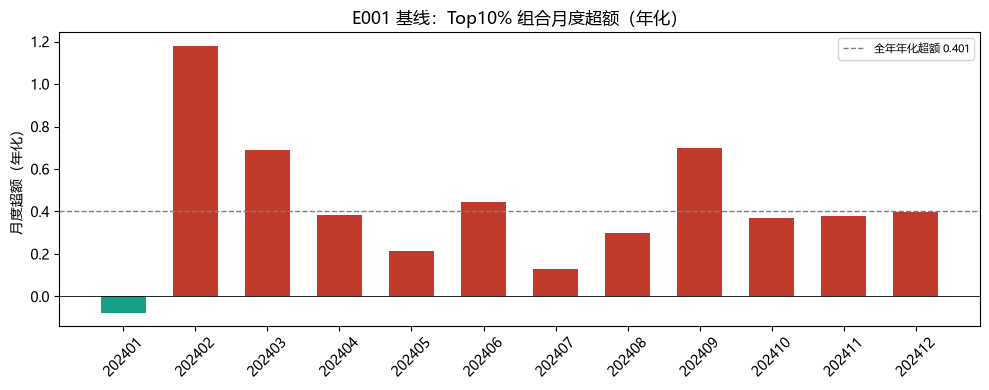

 month  n_days  excess_annual  excess_pos_ratio  top10_annual  market_annual  spread_annual
202401      22      -0.075599          0.500000     -2.527660      -2.452062       1.126830
202402      15       1.180492          0.800000      2.584568       1.404076       3.309518
202403      21       0.691550          0.761905      1.389900       0.698350       2.422935
202404      20       0.382731          0.600000      0.190907      -0.191824       2.709614
202405      20       0.213013          0.650000     -0.505872      -0.718884       2.154666
202406      19       0.446929          0.631579     -0.357164      -0.804093       1.870168
202407      23       0.127954          0.434783      0.108441      -0.019513       1.230962
202408      22       0.296783          0.818182     -0.284701      -0.581484       1.785635
202409      19       0.698256          0.578947      4.593463       3.895207       1.896864
202410      18       0.368850          0.500000     -0.342110      -0.710960    

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#c0392b" if v >= 0 else "#16a085" for v in bt_monthly["excess_annual"]]
ax.bar(bt_monthly["month"], bt_monthly["excess_annual"], color=colors, width=0.62)
ax.axhline(0, color="black", lw=0.6)
ax.axhline(bt_summary["annual_excess"], ls="--", lw=1, color="gray",
           label=f"全年年化超额 {bt_summary['annual_excess']:.3f}")
ax.set_ylabel("月度超额（年化）")
ax.set_title("E001 基线：Top10% 组合月度超额（年化）")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "top_excess_monthly_E001.png", dpi=150)
plt.show()
print(bt_monthly.to_string(index=False))

In [11]:
# 脆弱时段检查：Day 8 定位的 2024 年 1 月底–2 月初，在组合层面是什么表现
rel = cum_top10 / cum_mkt
drawdown = rel / rel.cummax() - 1
trough = drawdown.idxmin()
print(f"相对净值最大回撤 {bt_summary['relative_max_drawdown']:.2%}，谷底 {dates_bt.iloc[trough].date()}")
print("\n相对回撤最深的 8 天：")
for idx in drawdown.nsmallest(8).index:
    print(f"  {dates_bt.iloc[idx].date()}  相对回撤 {drawdown.iloc[idx]:+.2%}  当日超额 {bt_daily['top10_excess'].iloc[idx]:+.3%}")

janfeb = bt_daily[dates_bt.dt.month.isin([1, 2])]
r_top = (1 + janfeb["top10_ret"]).prod() - 1
r_mkt = (1 + janfeb["market_ret"]).prod() - 1
print(f"\n1–2 月整体：Top10 累计 {r_top:+.2%} vs 市场 {r_mkt:+.2%}，"
      f"相对超额 {(1 + janfeb['top10_ret']).prod() / (1 + janfeb['market_ret']).prod() - 1:+.2%}")
rest = bt_daily[~dates_bt.dt.month.isin([1, 2])]
r_top3 = (1 + rest["top10_ret"]).prod() - 1
r_mkt3 = (1 + rest["market_ret"]).prod() - 1
print(f"3–12 月整体：Top10 累计 {r_top3:+.2%} vs 市场 {r_mkt3:+.2%}，"
      f"相对超额 {(1 + rest['top10_ret']).prod() / (1 + rest['market_ret']).prod() - 1:+.2%}")

相对净值最大回撤 8.95%，谷底 2024-02-06

相对回撤最深的 8 天：
  2024-02-06  相对回撤 -8.95%  当日超额 -4.399%
  2024-02-02  相对回撤 -7.60%  当日超额 -3.587%
  2024-02-07  相对回撤 -5.75%  当日超额 +3.744%
  2024-02-05  相对回撤 -4.68%  当日超额 +3.226%
  2024-02-08  相对回撤 -4.18%  当日超额 +1.718%
  2024-02-01  相对回撤 -3.84%  当日超额 -0.805%
  2024-04-15  相对回撤 -3.78%  当日超额 -2.842%
  2024-02-19  相对回撤 -3.52%  当日超额 +0.697%

1–2 月整体：Top10 累计 -9.30% vs 市场 -13.69%，相对超额 +5.10%
3–12 月整体：Top10 累计 +47.25% vs 市场 +7.86%，相对超额 +36.52%


### 6.1 Top 组合分析小结（Day 6 / 9）

1. **口径零差异**：`backtest.py` 的逐日 `top10_excess` / `market_ret` 与 `official_eval` 的 `daily_metrics` 差 0.00e+00，年化 `top10_annual_ret` 0.3873 / `annual_excess` 0.4013 与 `metrics.json` 完全一致。
2. **排序信息集中在头部与尾部**：Top10 超额 +40.1% > Top20 +37.3%，Bottom10 年化 **−168.2%**，多空年化价差 +2.07。官方"只取 Top10%"的评分结构与该模型头部信息最密的特点匹配。
3. **月度超额 11/12 为正**，唯一负月 2024-01（年化 −7.6%），负超额集中在 0126–0130（单日 −0.82% / −0.56% / −1.43%）——与第 5 节 IC 崩塌时段完全重合。
4. **脆弱时段的真实代价有限**：相对净值最大回撤 8.95%（谷底 2024-02-06，当日超额 −4.40%；02-02 为 −3.59%，两天贡献大部分回撤），随后 V 型恢复（02-05 +3.23%、02-07 +3.74%）。1–2 月整体 Top10 仍跑赢市场 **+5.10%**（Top10 −9.30% vs 市场 −13.69%，绝对亏损主要是市场性下跌而非选股失败）。
5. **超额的空间分布**：3–12 月贡献绝大部分——Top10 累计 +47.25% vs 市场 +7.86%，相对超额 +36.52%。
6. **对 Day 10–12 的输入**：1–2 月的排序剧烈翻转同时带来 IC 崩塌、负超额与高换手，三者同源；平滑（α<1）恰好抑制这类噪声翻转，但也会钝化 2 月上旬的 V 型恢复。α 扫描时需单独检查 1–2 月段的表现，不能只看全年均值。